In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

---
# NumPy

In [63]:
random_matrix = np.random.randint(0, 10, size=(4, 5))
print("Матрица:")
print(random_matrix)

Матрица:
[[9 5 1 2 8]
 [4 6 9 0 9]
 [7 5 6 4 1]
 [1 9 1 2 4]]


In [64]:
part1, part2 = np.split(random_matrix, 2)

print("part1: ")
print(part1)
print("part2: ")
print(part2)

part1: 
[[9 5 1 2 8]
 [4 6 9 0 9]]
part2: 
[[7 5 6 4 1]
 [1 9 1 2 4]]


In [65]:
six_matrix = np.where(random_matrix==6)
print("X и Y:")
print(six_matrix)

X и Y:
(array([1, 2]), array([1, 2]))


In [66]:
print("Колво: ", np.size(six_matrix[0]))

Колво:  2


---
# Pandas


In [67]:
series_from_arr = pd.Series(random_matrix[0])
print("Series: ")
print(series_from_arr)

Series: 
0    9
1    5
2    1
3    2
4    8
dtype: int64


In [68]:
print("+1")
print(series_from_arr + 1)
print("-1")
print(series_from_arr - 1)
print("*2")
print(series_from_arr * 2)
print("/2")
print(series_from_arr / 2)

+1
0    10
1     6
2     2
3     3
4     9
dtype: int64
-1
0    8
1    4
2    0
3    1
4    7
dtype: int64
*2
0    18
1    10
2     2
3     4
4    16
dtype: int64
/2
0    4.5
1    2.5
2    0.5
3    1.0
4    4.0
dtype: float64


In [69]:
dataframe_from_arr = pd.DataFrame(random_matrix)
print("Dataframe: ")
print(dataframe_from_arr)

Dataframe: 
   0  1  2  3  4
0  9  5  1  2  8
1  4  6  9  0  9
2  7  5  6  4  1
3  1  9  1  2  4


In [70]:
dataframe_from_arr.columns = ["ПН", "ВТ", "СР", "ЧТ", "ПТ"]
print("Dataframe new: ")
print(dataframe_from_arr)

Dataframe new: 
   ПН  ВТ  СР  ЧТ  ПТ
0   9   5   1   2   8
1   4   6   9   0   9
2   7   5   6   4   1
3   1   9   1   2   4


In [71]:
df_new = dataframe_from_arr.drop(2)
print(df_new)
df_new = df_new.drop("ВТ", axis=1)
print(df_new)

   ПН  ВТ  СР  ЧТ  ПТ
0   9   5   1   2   8
1   4   6   9   0   9
3   1   9   1   2   4
   ПН  СР  ЧТ  ПТ
0   9   1   2   8
1   4   9   0   9
3   1   1   2   4


In [72]:
print(df_new.shape)

(3, 4)


In [73]:
coordinates = np.argwhere(dataframe_from_arr.values == 6)
print(f"Коорды:")
for row, col in coordinates:
    print(f"Строка: {dataframe_from_arr.index[row]}, Столбец: {dataframe_from_arr.columns[col]}")

Коорды:
Строка: 1, Столбец: ВТ
Строка: 2, Столбец: СР


---
# Часть2

In [74]:
df_stud = pd.read_csv("student_exam_performance.csv")

print(df_stud)

       student_id  age  gender education_level school_type family_income  \
0      STU_000001   20  Female     High School      Public        Middle   
1      STU_000002   17    Male     High School      Public        Middle   
2      STU_000003   18   Other   Undergraduate      Public        Middle   
3      STU_000004   20    Male     High School      Public        Middle   
4      STU_000005   16  Female     High School     Private          High   
...           ...  ...     ...             ...         ...           ...   
99995  STU_099996   17    Male   Undergraduate      Public  Upper-Middle   
99996  STU_099997   14  Female     High School      Public  Upper-Middle   
99997  STU_099998   16  Female     High School      Public  Upper-Middle   
99998  STU_099999   15  Female     High School     Private          High   
99999  STU_100000   18  Female   Undergraduate     Charter  Lower-Middle   

      parent_education urban_rural  previous_exam_score  previous_gpa  ...  \
0        

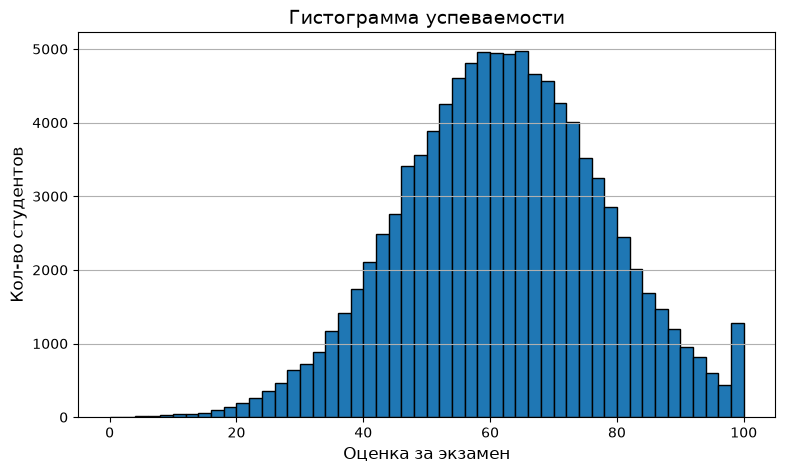

In [92]:
plt.figure(figsize=(9, 5))
plt.hist(df_stud['exam_score'], bins=50, edgecolor='black')

plt.title('Гистограмма успеваемости', fontsize=14)
plt.xlabel('Оценка за экзамен', fontsize=12)
plt.ylabel('Кол-во студентов', fontsize=12)
plt.grid(axis='y')
plt.show()


In [ ]:
print("Средняя: ", df_stud['exam_score'].mean())
print("Медиана: ", df_stud['exam_score'].median())

Средняя:  61.9500723
Медиана:  61.96


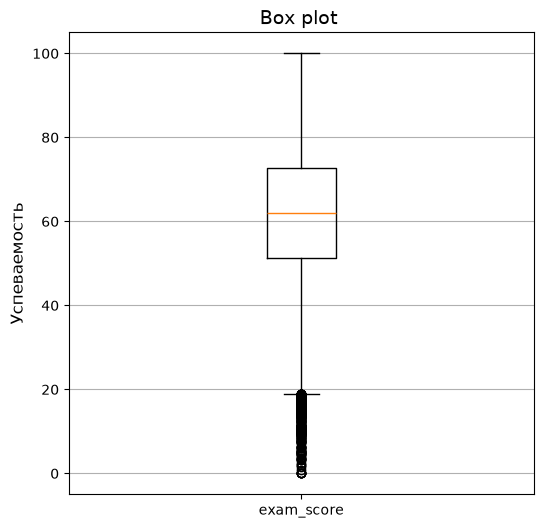

In [102]:
plt.figure(figsize=(6, 6))
plt.boxplot(df_stud['exam_score'].dropna())
plt.title('Box plot ', fontsize=14)
plt.ylabel('Успеваемость', fontsize=12)
plt.xticks([1], ['exam_score'])
plt.grid(axis='y')
plt.show()


In [103]:
print("describe")
print(df_stud['exam_score'].describe())

describe
count    100000.000000
mean         61.950072
std          15.863644
min           0.000000
25%          51.240000
50%          61.960000
75%          72.730000
max         100.000000
Name: exam_score, dtype: float64


In [ ]:
group_data = df_stud.groupby('motivation_level')['exam_score'].mean()
print(group_data)
print()
group_data = df_stud.groupby('exam_difficulty')['exam_score'].mean()
print(group_data)

motivation_level
High      61.959460
Low       61.871066
Medium    61.976086
Name: exam_score, dtype: float64

exam_difficulty
Easy      69.428998
Hard      54.420135
Medium    62.010284
Name: exam_score, dtype: float64

parent_education
Associate      61.829658
Bachelor       61.801911
Doctorate      62.132226
High School    62.031770
Master         62.072406
Name: exam_score, dtype: float64
